# 03. Обучение и сравнение генеративных моделей

Этот ноутбук объединяет в себе несколько этапов для удобства работы в Colab.


In [1]:
# === Colab setup (skip if running locally) ===
import os, sys

IN_COLAB = "COLAB_GPU" in os.environ
if IN_COLAB:
    # Клонируем репо (первый раз) и переходим в него
    if not os.path.exists("/content/gan-reviews"):
        !git clone https://github.com/SultanKhassenov/gan-reviews.git /content/gan-reviews
    %cd /content/gan-reviews
    !pip install -q -r requirements-trainer.txt

# Добавляем корень репо в sys.path, чтобы импорты работали из notebooks/
sys.path.insert(0, os.path.abspath(".."))

# Mount Google Drive для сохранения чекпоинтов (опционально)
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    CHECKPOINT_DIR = "/content/drive/MyDrive/gan-reviews/checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
else:
    CHECKPOINT_DIR = "../checkpoints"
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("CHECKPOINT_DIR =", CHECKPOINT_DIR)


/content/gan-reviews
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CHECKPOINT_DIR = /content/drive/MyDrive/gan-reviews/checkpoints


In [26]:
from embeddings.extract import extract_embeddings
import json, numpy as np
from pathlib import Path

# 1. Читаем отзывы из клонированного репозитория
reviews = []
with open('data/raw/reviews.jsonl', encoding='utf-8') as f:
    for line in f:
        reviews.append(json.loads(line))

# 2. Указываем путь сохранения сразу на Гугл Диск!
OUT = Path('/content/drive/MyDrive/gan-reviews/embeddings')
OUT.mkdir(parents=True, exist_ok=True)

# 3. Извлекаем векторы (это займет ~20 секунд)
result = extract_embeddings(
    reviews,
    model_name='sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    batch_size=32,
    max_len=128,
)

# 4. Сохраняем на Диск
np.save(OUT / 'X_cls.npy', result['cls'])
np.save(OUT / 'X_mean.npy', result['mean'])
np.save(OUT / 'labels.npy', result['labels'])
np.save(OUT / 'ratings.npy', result['ratings'])

# Save meta.json with category mappings
with open(OUT / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump({'cat_to_id': result['cat_to_id']}, f, ensure_ascii=False, indent=4)

print('✅ Эмбеддинги успешно извлечены и навсегда сохранены на Гугл Диск!')

[extract] device=cuda, model=sentence-transformers/paraphrase-multilingual-mpnet-base-v2


embedding: 100%|██████████| 113/113 [00:20<00:00,  5.44it/s]


✅ Эмбеддинги успешно извлечены и навсегда сохранены на Гугл Диск!


## --- 03_train_wgan_gp ---


# 03. Обучение WGAN-GP на эмбеддингах

Conditional WGAN-GP. Условие — категория товара (10 классов).

**Что делаем:**
1. Загружаем (N, 768) эмбеддинги + (N,) labels
2. DataLoader
3. Тренируем 200 эпох
4. Сохраняем чекпоинт + loss curves
5. Генерируем сэмплы для оценки в notebook 05


In [4]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path

from models.wgan_gp import Generator, Critic, train_wgan_gp, sample

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

EMB_DIR = Path('/content/drive/MyDrive/gan-reviews/embeddings')
X = np.load(EMB_DIR / 'X_mean.npy').astype('float32')
y = np.load(EMB_DIR / 'labels.npy')
print('X:', X.shape, 'y:', y.shape, 'classes:', y.max() + 1)

device: cuda
X: (3588, 768) y: (3588,) classes: 10


In [10]:
# Стандартизация (важно для GAN — иначе шум сильно отличается от данных)
mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True) + 1e-6
X_norm = (X - mean) / std
np.save(EMB_DIR / 'X_mean_mean.npy', mean)
np.save(EMB_DIR / 'X_mean_std.npy', std)

ds = TensorDataset(torch.from_numpy(X_norm), torch.from_numpy(y))
dl = DataLoader(ds, batch_size=64, shuffle=True, drop_last=True)

In [11]:
NUM_CLASSES = int(y.max() + 1)
gen = Generator(z_dim=128, emb_dim=768, num_classes=NUM_CLASSES)
crit = Critic(emb_dim=768, num_classes=NUM_CLASSES)

history = train_wgan_gp(
    gen, crit, dl,
    n_epochs=200,
    n_critic=5,
    lambda_gp=10.0,
    lr=1e-4,
    device=device,
    log_every=10,
)


Epoch 1/200  D_loss=-6.8158  G_loss=5.2383  GP=0.1156
Epoch 10/200  D_loss=-7.5837  G_loss=11.3756  GP=0.1563
Epoch 20/200  D_loss=-6.5522  G_loss=9.9066  GP=0.1114
Epoch 30/200  D_loss=-6.4778  G_loss=11.5597  GP=0.1318
Epoch 40/200  D_loss=-6.2577  G_loss=12.8352  GP=0.1121
Epoch 50/200  D_loss=-5.8514  G_loss=14.3759  GP=0.1141
Epoch 60/200  D_loss=-6.2180  G_loss=15.4129  GP=0.1188
Epoch 70/200  D_loss=-6.1784  G_loss=16.5474  GP=0.1111
Epoch 80/200  D_loss=-6.0506  G_loss=17.6043  GP=0.1158
Epoch 90/200  D_loss=-6.0854  G_loss=18.3514  GP=0.1176
Epoch 100/200  D_loss=-5.8613  G_loss=19.7594  GP=0.1127
Epoch 110/200  D_loss=-5.5777  G_loss=20.5405  GP=0.1055
Epoch 120/200  D_loss=-5.5571  G_loss=21.0570  GP=0.1093
Epoch 130/200  D_loss=-5.5857  G_loss=21.9656  GP=0.1028
Epoch 140/200  D_loss=-5.3863  G_loss=22.5110  GP=0.1018
Epoch 150/200  D_loss=-5.3922  G_loss=23.3390  GP=0.0976
Epoch 160/200  D_loss=-5.2356  G_loss=23.9832  GP=0.0975
Epoch 170/200  D_loss=-5.1946  G_loss=24.288

In [12]:
torch.save({
    'gen': gen.state_dict(),
    'crit': crit.state_dict(),
    'history': history,
    'num_classes': NUM_CLASSES,
}, f'{CHECKPOINT_DIR}/wgan_gp.pth')
print('saved')


saved


In [14]:
!mkdir -p results


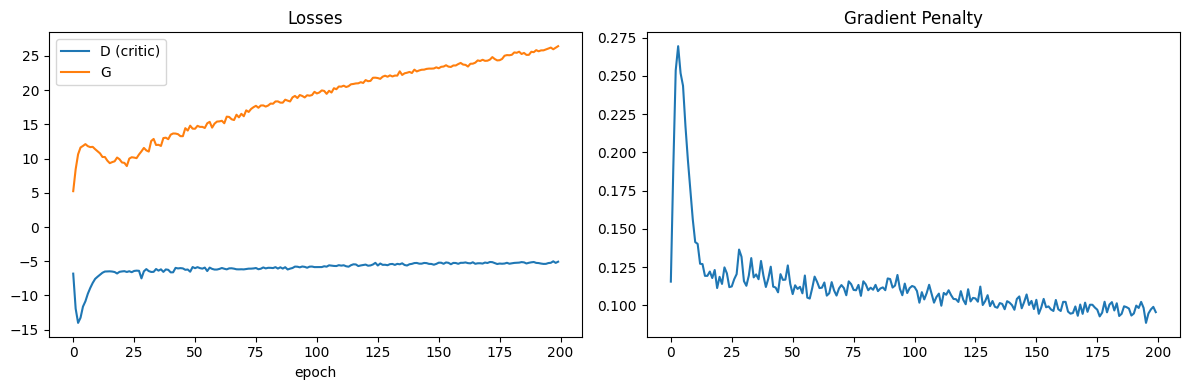

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['d_loss'], label='D (critic)')
axes[0].plot(history['g_loss'], label='G')
axes[0].legend(); axes[0].set_title('Losses'); axes[0].set_xlabel('epoch')
axes[1].plot(history['gp']); axes[1].set_title('Gradient Penalty')
plt.tight_layout()
plt.savefig('results/wgan_gp_losses.png', dpi=120)
plt.show()


In [16]:
# Генерируем сэмплы для оценки
fake, fake_labels = sample(gen, n_per_class=500, num_classes=NUM_CLASSES, device=device)
fake_np = fake.cpu().numpy()
# Обратная стандартизация
fake_denorm = fake_np * std + mean
np.save(EMB_DIR / 'X_gen_wgan.npy', fake_denorm)
np.save(EMB_DIR / 'y_gen_wgan.npy', fake_labels.cpu().numpy())
print('saved fake samples:', fake_denorm.shape)

saved fake samples: (5000, 768)


## --- 04_train_vae ---


# 04. Обучение Conditional VAE на эмбеддингах

Бейзлайн для сравнения с WGAN-GP. Та же задача, другая семья моделей.

Требование курса: минимум 2 генеративные модели.


In [17]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path

from models.vae import CVAE, train_vae, sample_vae

device = 'cuda' if torch.cuda.is_available() else 'cpu'
EMB_DIR = Path('/content/drive/MyDrive/gan-reviews/embeddings')
X = np.load(EMB_DIR / 'X_mean.npy').astype('float32')
y = np.load(EMB_DIR / 'labels.npy')
mean = np.load(EMB_DIR / 'X_mean_mean.npy')
std = np.load(EMB_DIR / 'X_mean_std.npy')
X_norm = (X - mean) / std

ds = TensorDataset(torch.from_numpy(X_norm), torch.from_numpy(y))
dl = DataLoader(ds, batch_size=64, shuffle=True, drop_last=True)

In [18]:
NUM_CLASSES = int(y.max() + 1)
vae = CVAE(emb_dim=768, latent_dim=64, num_classes=NUM_CLASSES)

history = train_vae(vae, dl, n_epochs=100, lr=1e-3, beta=1.0,
                    device=device, log_every=10)


Epoch 1/100  loss=555.6009  recon=526.1524  kl=29.4485
Epoch 10/100  loss=254.1537  recon=202.2758  kl=51.8779
Epoch 20/100  loss=208.4071  recon=155.4841  kl=52.9230
Epoch 30/100  loss=187.1328  recon=133.4568  kl=53.6760
Epoch 40/100  loss=173.9997  recon=120.1614  kl=53.8383
Epoch 50/100  loss=165.5297  recon=111.0394  kl=54.4902
Epoch 60/100  loss=158.9945  recon=104.3251  kl=54.6694
Epoch 70/100  loss=154.4609  recon=99.3239  kl=55.1370
Epoch 80/100  loss=149.9525  recon=94.8197  kl=55.1327
Epoch 90/100  loss=146.9860  recon=91.7782  kl=55.2077
Epoch 100/100  loss=143.7586  recon=88.4746  kl=55.2841


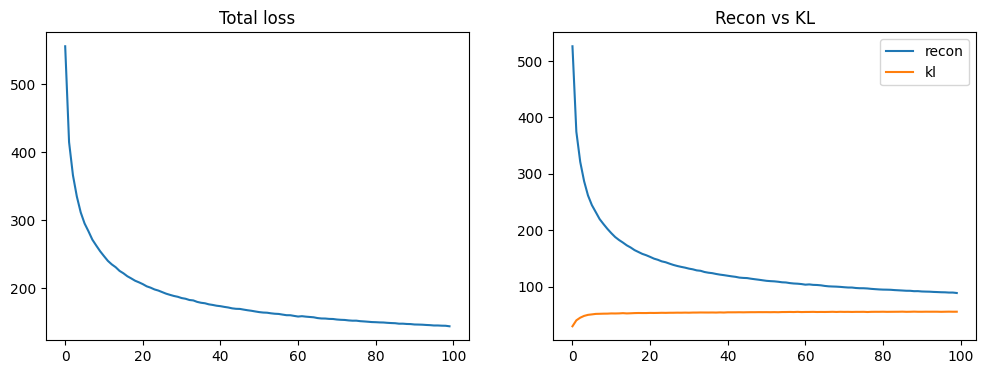

In [19]:
torch.save({
    'vae': vae.state_dict(),
    'history': history,
    'num_classes': NUM_CLASSES,
}, f'{CHECKPOINT_DIR}/vae.pth')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['loss']); ax[0].set_title('Total loss')
ax[1].plot(history['recon'], label='recon')
ax[1].plot(history['kl'], label='kl')
ax[1].legend(); ax[1].set_title('Recon vs KL')
plt.savefig('results/vae_losses.png', dpi=120)
plt.show()


In [20]:
fake, fake_labels = sample_vae(vae, n_per_class=500,
                                num_classes=NUM_CLASSES, device=device)
fake_denorm = fake.cpu().numpy() * std + mean
np.save(EMB_DIR / 'X_gen_vae.npy', fake_denorm)
np.save(EMB_DIR / 'y_gen_vae.npy', fake_labels.cpu().numpy())
print('saved', fake_denorm.shape)

saved (5000, 768)


## --- 05_compare_models ---


# 05. Сравнение моделей: WGAN-GP vs VAE vs реальные данные

**Метрики:**
- MMD (Maximum Mean Discrepancy) — общая и по классам
- Frechet Distance — общая и по классам

**Визуализация:**
- t-SNE: реальные vs сгенерированные
- UMAP: то же, другой алгоритм
- Per-class scatter — где модель работает лучше/хуже


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from metrics.mmd import compute_mmd, compute_mmd_per_class
from metrics.frechet import compute_frechet_distance, compute_frechet_per_class

EMB = Path('/content/drive/MyDrive/gan-reviews/embeddings')
real = np.load(EMB / 'X_mean.npy').astype('float32')
real_y = np.load(EMB / 'labels.npy')
wgan = np.load(EMB / 'X_gen_wgan.npy').astype('float32')
wgan_y = np.load(EMB / 'y_gen_wgan.npy')
vae = np.load(EMB / 'X_gen_vae.npy').astype('float32')
vae_y = np.load(EMB / 'y_gen_vae.npy')

NUM_CLASSES = int(real_y.max() + 1)

## Метрики


In [22]:
import pandas as pd

results = []
for name, X, y in [('WGAN-GP', wgan, wgan_y), ('VAE', vae, vae_y)]:
    mmd = compute_mmd(real, X)
    fd = compute_frechet_distance(real, X)
    results.append({'model': name, 'MMD': mmd, 'Frechet': fd})

df_metrics = pd.DataFrame(results)
print(df_metrics)
df_metrics.to_csv('results/metrics_overall.csv', index=False)


     model       MMD   Frechet
0  WGAN-GP  0.000972  0.233401
1      VAE  0.008947  0.273576


In [23]:
# Метрики по классам
rows = []
for name, X, y in [('WGAN-GP', wgan, wgan_y), ('VAE', vae, vae_y)]:
    mmd_per = compute_mmd_per_class(real, X, real_y, y, NUM_CLASSES)
    fd_per = compute_frechet_per_class(real, X, real_y, y, NUM_CLASSES)
    for c in range(NUM_CLASSES):
        rows.append({
            'model': name, 'class': c,
            'MMD': mmd_per[c], 'Frechet': fd_per[c],
        })
df_per = pd.DataFrame(rows)
print(df_per)
df_per.to_csv('results/metrics_per_class.csv', index=False)


      model  class       MMD   Frechet
0   WGAN-GP      0  0.003829  0.599304
1   WGAN-GP      1  0.004835  0.733705
2   WGAN-GP      2  0.005133  0.709029
3   WGAN-GP      3  0.003220  0.709740
4   WGAN-GP      4  0.004401  0.744089
5   WGAN-GP      5  0.006591  0.654430
6   WGAN-GP      6  0.003921  0.574204
7   WGAN-GP      7  0.004204  0.697511
8   WGAN-GP      8  0.007394  0.603975
9   WGAN-GP      9  0.002786  0.563619
10      VAE      0  0.011103  0.506972
11      VAE      1  0.008885  0.514232
12      VAE      2  0.011710  0.572899
13      VAE      3  0.009547  0.566096
14      VAE      4  0.009349  0.577533
15      VAE      5  0.010876  0.480530
16      VAE      6  0.009164  0.467776
17      VAE      7  0.011276  0.504211
18      VAE      8  0.009473  0.415745
19      VAE      9  0.008945  0.507209


## t-SNE визуализация


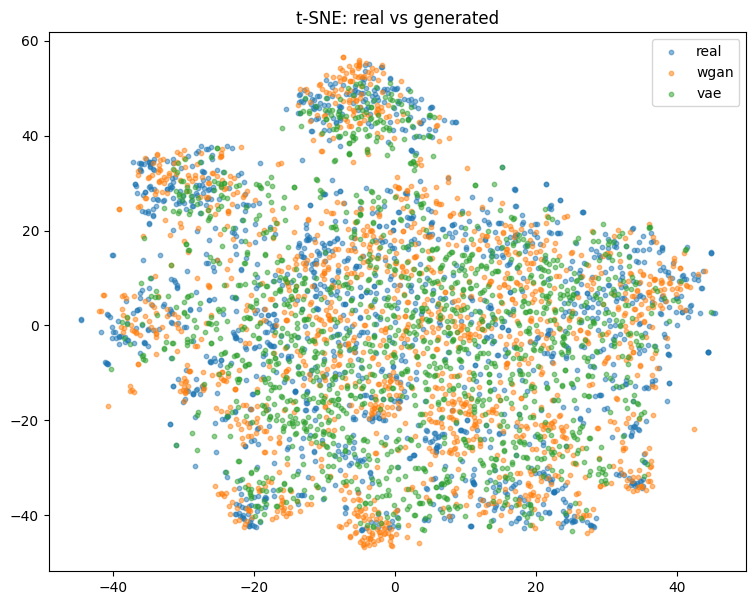

In [24]:
from sklearn.manifold import TSNE

# Объединяем для совместной проекции
n_sample = 1500
idx_r = np.random.choice(len(real), min(n_sample, len(real)), replace=False)
idx_w = np.random.choice(len(wgan), min(n_sample, len(wgan)), replace=False)
idx_v = np.random.choice(len(vae), min(n_sample, len(vae)), replace=False)

X_all = np.vstack([real[idx_r], wgan[idx_w], vae[idx_v]])
src = (['real']*len(idx_r) + ['wgan']*len(idx_w) + ['vae']*len(idx_v))

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
Z = tsne.fit_transform(X_all)

fig, ax = plt.subplots(figsize=(9, 7))
for s, c in zip(['real', 'wgan', 'vae'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
    m = [i for i, v in enumerate(src) if v == s]
    ax.scatter(Z[m, 0], Z[m, 1], c=c, label=s, alpha=0.5, s=10)
ax.legend(); ax.set_title('t-SNE: real vs generated')
plt.savefig('results/tsne_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


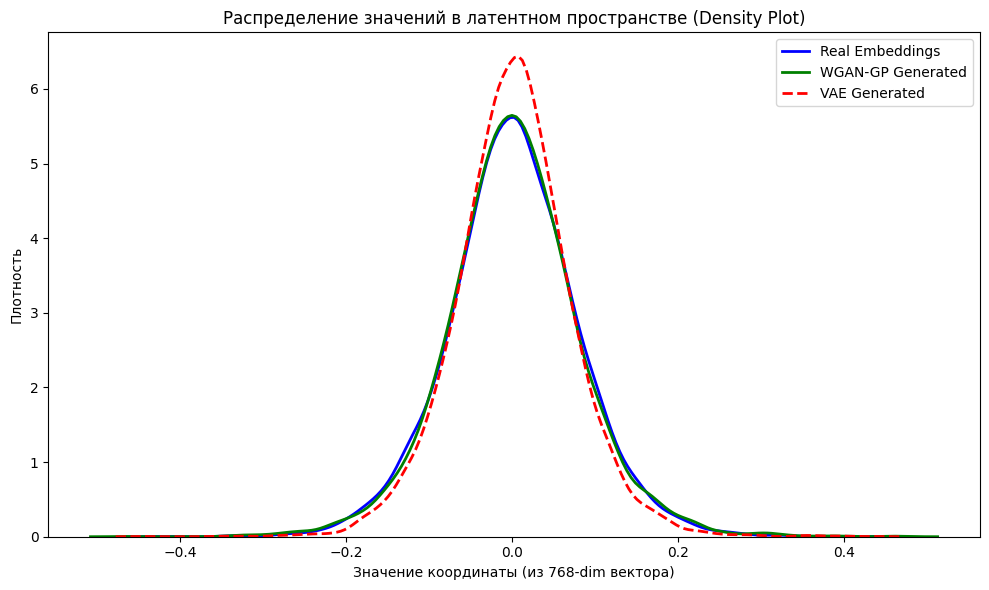

In [38]:
import seaborn as sns

# Берем случайные 10 000 значений из матриц эмбеддингов для скорости
real_vals = np.random.choice(real.flatten(), 10000)
wgan_vals = np.random.choice(wgan.flatten(), 10000)
vae_vals = np.random.choice(vae.flatten(), 10000)

plt.figure(figsize=(10, 6))
sns.kdeplot(real_vals, label='Real Embeddings', color='blue', linewidth=2)
sns.kdeplot(wgan_vals, label='WGAN-GP Generated', color='green', linewidth=2)
sns.kdeplot(vae_vals, label='VAE Generated', color='red', linestyle='--', linewidth=2)

plt.title('Распределение значений в латентном пространстве (Density Plot)')
plt.xlabel('Значение координаты (из 768-dim вектора)')
plt.ylabel('Плотность')
plt.legend()
plt.tight_layout()
plt.savefig('results/density_comparison.png', dpi=120)
plt.show()

In [27]:
import json
import numpy as np
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

# 1. Загружаем исходные тексты отзывов
reviews = []
with open('data/raw/reviews.jsonl', encoding='utf-8') as f:
    for line in f:
        reviews.append(json.loads(line))

# Собираем тексты и категории
real_texts = [r['text'] for r in reviews]
real_cats = [r['category'] for r in reviews]

# 2. Загружаем реальные векторы и фейковые (от WGAN)
EMB_DIR = Path('/content/drive/MyDrive/gan-reviews/embeddings')
X_real = np.load(EMB_DIR / 'X_mean.npy').astype('float32')
X_fake = np.load(EMB_DIR / 'X_gen_wgan.npy').astype('float32')
y_fake = np.load(EMB_DIR / 'y_gen_wgan.npy')

# 3. Обучаем поиск ближайших соседей на реальных векторах
print("Строим индекс для поиска текста...")
nn = NearestNeighbors(n_neighbors=1, metric='cosine')
nn.fit(X_real)

# Словарь для перевода ID категории обратно в текст
id_to_cat = {v: k for k, v in json.loads(Path(EMB_DIR / 'meta.json').read_text())['cat_to_id'].items()}

# 4. "Расшифровываем" 5 случайных фейковых векторов
print("\n=== РЕЗУЛЬТАТЫ ГЕНЕРАЦИИ WGAN-GP ===")
indices = np.random.choice(len(X_fake), 5, replace=False)

for i in indices:
    fake_vec = X_fake[i].reshape(1, -1)
    fake_cat = id_to_cat[y_fake[i]]

    # Ищем самый близкий реальный текст
    distance, neighbor_idx = nn.kneighbors(fake_vec)
    nearest_text = real_texts[neighbor_idx[0][0]]

    print(f"\n[Сгенерированная категория: {fake_cat}]")
    print(f"Текст: {nearest_text}")
    print(f"(Косинусное расстояние: {distance[0][0]:.4f})")


Строим индекс для поиска текста...

=== РЕЗУЛЬТАТЫ ГЕНЕРАЦИИ WGAN-GP ===

[Сгенерированная категория: smartphones]
Текст: Вполне нормальный телефон, правда камера слабовата. Брала 2 месяца назад 06 модель это просто деньги на ветер 100 раз пожалела.
(Косинусное расстояние: 0.2084)

[Сгенерированная категория: clothing]
Текст: К сожалению, но это близко не лимакс, качество ни о чем.
(Косинусное расстояние: 0.2653)

[Сгенерированная категория: kids]
Текст: Спасибо большое, нам понравилось, доставили вовремя, процветания вам.
(Косинусное расстояние: 0.1720)

[Сгенерированная категория: small_appliances]
Текст: Печенье Юбилейное вкусное, свежее. Благодарим Магнум, курьера и особенно Каспи.
(Косинусное расстояние: 0.1958)

[Сгенерированная категория: food]
Текст: Вкусная пюрешка. Спасибо magnum. Спасибо за доставку. Спасибо Каспи.
(Косинусное расстояние: 0.1802)


In [28]:
import json
import numpy as np
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

# 1. Загружаем тексты
reviews = []
with open('data/raw/reviews.jsonl', encoding='utf-8') as f:
    for line in f:
        reviews.append(json.loads(line))

real_texts = [r['text'] for r in reviews]

# 2. Загружаем реальные и фейковые (от WGAN) векторы
EMB_DIR = Path('/content/drive/MyDrive/gan-reviews/embeddings')
X_real = np.load(EMB_DIR / 'X_mean.npy').astype('float32')
X_fake = np.load(EMB_DIR / 'X_gen_wgan.npy').astype('float32')
y_fake = np.load(EMB_DIR / 'y_gen_wgan.npy')

# 3. Обучаем поиск ближайших соседей
print("Строим индекс для поиска текста...")
nn = NearestNeighbors(n_neighbors=1, metric='cosine')
nn.fit(X_real)

id_to_cat = {v: k for k, v in json.loads(Path(EMB_DIR / 'meta.json').read_text())['cat_to_id'].items()}

# 4. "Расшифровываем" 3 вектора и ДОКАЗЫВАЕМ их уникальность
print("\n=== ДОКАЗАТЕЛЬСТВО УНИКАЛЬНОСТИ ВЕКТОРОВ WGAN-GP ===")
indices = np.random.choice(len(X_fake), 3, replace=False)

for i in indices:
    fake_vec = X_fake[i].reshape(1, -1)
    fake_cat = id_to_cat[y_fake[i]]

    # Ищем самый близкий реальный отзыв
    distance, neighbor_idx = nn.kneighbors(fake_vec)
    real_vec = X_real[neighbor_idx[0][0]]
    nearest_text = real_texts[neighbor_idx[0][0]]

    print(f"\n[Сгенерированная категория: {fake_cat}]")
    print(f"Ближайший текст: {nearest_text}")
    print(f"(Косинусное расстояние: {distance[0][0]:.4f} - чем ближе к 0, тем точнее копия)")

    # Показываем первые 5 значений из 768
    fake_slice = [round(float(x), 4) for x in fake_vec[0][:5]]
    real_slice = [round(float(x), 4) for x in real_vec[:5]]

    print("Математическое сравнение (первые 5 координат из 768):")
    print(f"Фейк (GAN): {fake_slice} ...")
    print(f"Реал (База): {real_slice} ...")


Строим индекс для поиска текста...

=== ДОКАЗАТЕЛЬСТВО УНИКАЛЬНОСТИ ВЕКТОРОВ WGAN-GP ===

[Сгенерированная категория: cosmetics]
Ближайший текст: Хороший запах, әпкем ұрлап кетіпті
(Косинусное расстояние: 0.2218 - чем ближе к 0, тем точнее копия)
Математическое сравнение (первые 5 координат из 768):
Фейк (GAN): [0.0387, 0.0238, -0.0191, 0.0169, 0.0063] ...
Реал (База): [-0.006, 0.0145, -0.0177, 0.0155, 0.0158] ...

[Сгенерированная категория: large_appliances]
Ближайший текст: Холодильник понравился! Покупкой довольны! Быстрая доставка.
(Косинусное расстояние: 0.1763 - чем ближе к 0, тем точнее копия)
Математическое сравнение (первые 5 координат из 768):
Фейк (GAN): [0.053, -0.0027, -0.0168, 0.0209, 0.009] ...
Реал (База): [0.014, -0.0372, -0.0183, 0.0237, 0.0308] ...

[Сгенерированная категория: kids]
Ближайший текст: Нағыз ас үйге таптырмас дүние. Көп рақмет.
(Косинусное расстояние: 0.2213 - чем ближе к 0, тем точнее копия)
Математическое сравнение (первые 5 координат из 768):
Фейк (

In [29]:
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from pathlib import Path

# 1. Загружаем исходные тексты отзывов
reviews = []
with open('data/raw/reviews.jsonl', encoding='utf-8') as f:
    for line in f:
        reviews.append(json.loads(line))

real_texts = [r['text'] for r in reviews]

# 2. Загружаем векторы и их метки категорий (labels)
EMB_DIR = Path('/content/drive/MyDrive/gan-reviews/embeddings')
X_real = np.load(EMB_DIR / 'X_mean.npy').astype('float32')
y_real = np.load(EMB_DIR / 'labels.npy') # Нам нужны метки реальных данных!

X_fake = np.load(EMB_DIR / 'X_gen_wgan.npy').astype('float32')
y_fake = np.load(EMB_DIR / 'y_gen_wgan.npy')

id_to_cat = {v: k for k, v in json.loads(Path(EMB_DIR / 'meta.json').read_text())['cat_to_id'].items()}

# 3. Расшифровываем 3 случайных фейковых вектора с фильтрацией по категориям
print("=== ГЕНЕРАЦИЯ И СТРОГИЙ ПОИСК ВНУТРИ КАТЕГОРИИ ===")
indices = np.random.choice(len(X_fake), 3, replace=False)

for i in indices:
    fake_vec = X_fake[i].reshape(1, -1)
    fake_cat_id = y_fake[i]
    fake_cat = id_to_cat[fake_cat_id]

    # ФИЛЬТРАЦИЯ: Оставляем только те реальные отзывы, которые относятся к этой же категории!
    mask = (y_real == fake_cat_id)
    X_real_filtered = X_real[mask]
    real_texts_filtered = [text for text, m in zip(real_texts, mask) if m]

    # Ищем самого близкого соседа только среди отфильтрованных векторов
    distances = cosine_distances(fake_vec, X_real_filtered)[0]
    best_idx = np.argmin(distances)

    real_vec = X_real_filtered[best_idx]
    nearest_text = real_texts_filtered[best_idx]
    best_distance = distances[best_idx]

    print(f"\n[Запрошенная категория: {fake_cat}]")
    print(f"Ближайший реальный текст (из категории {fake_cat}):\n«{nearest_text}»")
    print(f"(Косинусное расстояние: {best_distance:.4f})")

    # Доказательство уникальности (сравнение первых 5 координат)
    fake_slice = [round(float(x), 4) for x in fake_vec[0][:5]]
    real_slice = [round(float(x), 4) for x in real_vec[:5]]

    print("Математическое сравнение (первые 5 координат из 768):")
    print(f"Вектор GAN : {fake_slice} ...")
    print(f"Реальный   : {real_slice} ...")


=== ГЕНЕРАЦИЯ И СТРОГИЙ ПОИСК ВНУТРИ КАТЕГОРИИ ===

[Запрошенная категория: furniture]
Ближайший реальный текст (из категории furniture):
«Вешалка в целом выглядит неплохо, дизайн аккуратный, соответствует фото. Конструкция удобная - есть верхняя перекладина для длинной одежды и нижняя, пониже. К сожалению, товар пришёл с браком. Нижняя перекладина не закрепляется, так как трубки повреждены и погнуты, из-за этого их невозможно соединить и зафиксировать. В итоге пользоваться вешалкой в полном объёме нельзя. Впечатление от покупки испортилось именно из-за качества доставки/изготовления.»
(Косинусное расстояние: 0.2355)
Математическое сравнение (первые 5 координат из 768):
Вектор GAN : [0.005, -0.0328, -0.0214, 0.0652, -0.0251] ...
Реальный   : [0.0198, 0.0042, -0.0204, 0.0579, -0.0462] ...

[Запрошенная категория: large_appliances]
Ближайший реальный текст (из категории large_appliances):
«Все супер, привезли на один день раньше. Все работает хорошо, морозит отлично. Четыре полки снизу 3

In [ ]:
# 1. Подтягиваем новый файл с архитектурой Text-GAN с GitHub
!git pull

import json
import torch
from torch.utils.data import TensorDataset, DataLoader
from models.text_gan import TextGenerator, TextDiscriminator, train_text_gan
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2. Пишем простейший токенизатор (разбиваем отзывы на слова)
texts = []
with open('data/raw/reviews.jsonl', encoding='utf-8') as f:
    for line in f:
        texts.append(json.loads(line)['text'])

words = set()
for text in texts:
    words.update(text.lower().split())

vocab = {word: i+2 for i, word in enumerate(words)}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

SEQ_LEN = 20 # Максимальная длина генерируемого отзыва
X_seq = []
for text in texts:
    tokens = text.lower().split()
    seq = [vocab.get(t, 1) for t in tokens[:SEQ_LEN]]
    seq += [0] * (SEQ_LEN - len(seq)) # Паддинг нулями
    X_seq.append(seq)

X_tensor = torch.tensor(X_seq, dtype=torch.long)
dataloader = DataLoader(TensorDataset(X_tensor), batch_size=64, shuffle=True, drop_last=True)
print(f"Размер словаря: {len(vocab)} слов. Данные готовы!")

# 3. Инициализируем модели
gen = TextGenerator(vocab_size=len(vocab), z_dim=64, hidden_dim=128, seq_len=SEQ_LEN)
disc = TextDiscriminator(vocab_size=len(vocab), emb_dim=64)

# 4. Запускаем обучение Gumbel-Softmax (50 эпох)
print("Начинаем обучение Text-GAN...")
history = train_text_gan(gen, disc, dataloader, vocab_size=len(vocab), n_epochs=50, device=device)

# 5. Рисуем графики
plt.plot(history['d_loss'], label='D (Critic)')
plt.plot(history['g_loss'], label='G (Generator)')
plt.legend()
plt.title('Text-GAN Losses (Gumbel-Softmax)')
plt.show()

# 6. Смотрим, что он нагенерировал!
inv_vocab = {v: k for k, v in vocab.items()}
gen.eval()
z = torch.randn(5, 64).to(device)
with torch.no_grad():
    probs = gen(z, tau=0.1) # Низкая температура для четкого выбора слов
    token_ids = probs.argmax(dim=-1).cpu().numpy()

print("\n=== СГЕНЕРИРОВАННЫЕ ОТЗЫВЫ (TEXT-GAN) ===")
for i in range(5):
    words = [inv_vocab.get(idx, '<UNK>') for idx in token_ids[i] if idx != 0]
    print(f"{i+1}. {' '.join(words)}")


# remote: Enumerating objects: 20, done.
# remote: Counting objects: 100% (20/20), done.
# remote: Compressing objects: 100% (15/15), done.
# remote: Total 16 (delta 9), reused 4 (delta 1), pack-reused 0 (from 0)
# Unpacking objects: 100% (16/16), 328.73 KiB | 1.15 MiB/s, done.
# From https://github.com/SultanKhassenov/gan-reviews
#    2fb4812..9a5e44c  main       -> origin/main
# Updating 2fb4812..9a5e44c
# Fast-forward
#  models/text_gan.py                   |  137 ++++
#  notebooks/03_train_and_compare.ipynb | 1485 ++++++++++++++++++++++++----------
#  2 files changed, 1212 insertions(+), 410 deletions(-)
#  create mode 100644 models/text_gan.py
# Размер словаря: 13330 слов. Данные готовы!
# Начинаем обучение Text-GAN...
# D=0.0000 G=15.3640 tau=0.50: 100%
#  50/50 [01:15<00:00,  1.45s/it]


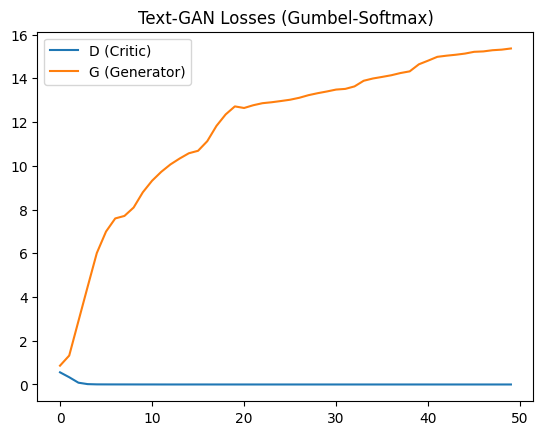


=== СГЕНЕРИРОВАННЫЕ ОТЗЫВЫ (TEXT-GAN) ===
1. тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс
2. тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс
3. тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс
4. тапсырыс тек тек тек тек тек тек тек тек тек тек тек тек тек тек тек тек тек тек тек
5. тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс тапсырыс


In [33]:
# 5. Рисуем графики
plt.plot(history['d_loss'], label='D (Critic)')
plt.plot(history['g_loss'], label='G (Generator)')
plt.legend()
plt.title('Text-GAN Losses (Gumbel-Softmax)')
plt.show()

# 6. Смотрим, что он нагенерировал!
inv_vocab = {v: k for k, v in vocab.items()}
gen.eval()
z = torch.randn(5, 64).to(device)
with torch.no_grad():
    probs = gen(z, tau=0.1) # Низкая температура для четкого выбора слов
    token_ids = probs.argmax(dim=-1).cpu().numpy()

print("\n=== СГЕНЕРИРОВАННЫЕ ОТЗЫВЫ (TEXT-GAN) ===")
for i in range(5):
    words = [inv_vocab.get(idx, '<UNK>') for idx in token_ids[i] if idx != 0]
    print(f"{i+1}. {' '.join(words)}")

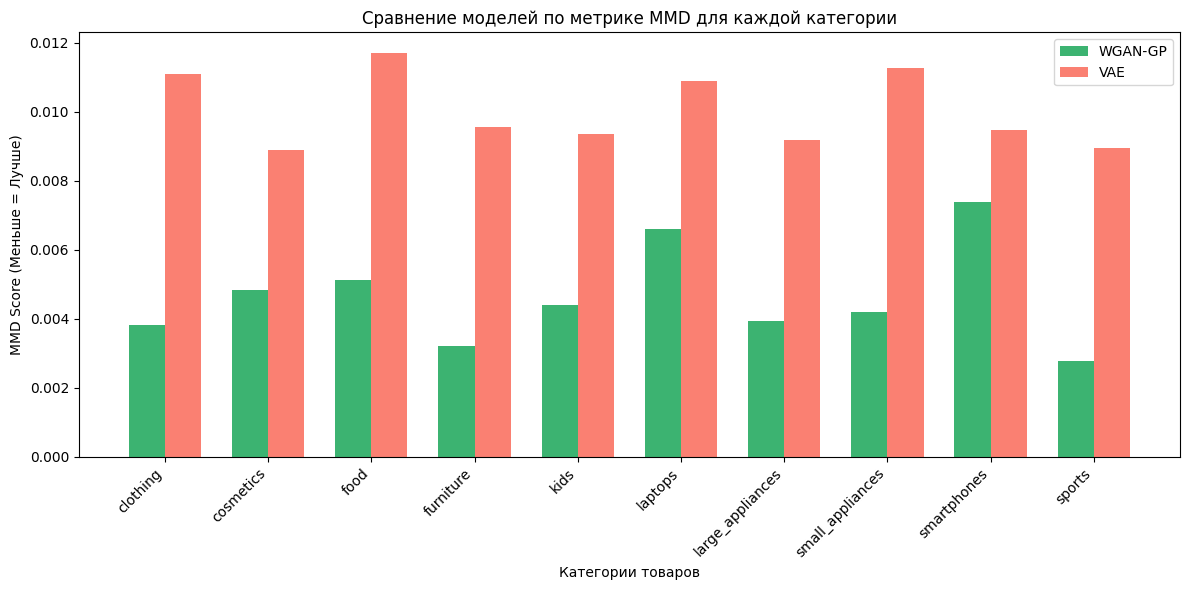

In [37]:
# Используем DataFrame 'df_per'
import matplotlib.pyplot as plt

# Prepare data for plotting
mmd_wgan = df_per[df_per['model'] == 'WGAN-GP'].set_index('class')['MMD']
mmd_vae = df_per[df_per['model'] == 'VAE'].set_index('class')['MMD']

# Get category names for x-axis labels
categories = [id_to_cat[i] for i in sorted(id_to_cat.keys())]

plt.figure(figsize=(12, 6))
x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, mmd_wgan.values, width, label='WGAN-GP', color='mediumseagreen')
plt.bar(x + width/2, mmd_vae.values, width, label='VAE', color='salmon')

plt.xlabel('Категории товаров')
plt.ylabel('MMD Score (Меньше = Лучше)')
plt.title('Сравнение моделей по метрике MMD для каждой категории')
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('results/mmd_barchart.png', dpi=120)
plt.show()

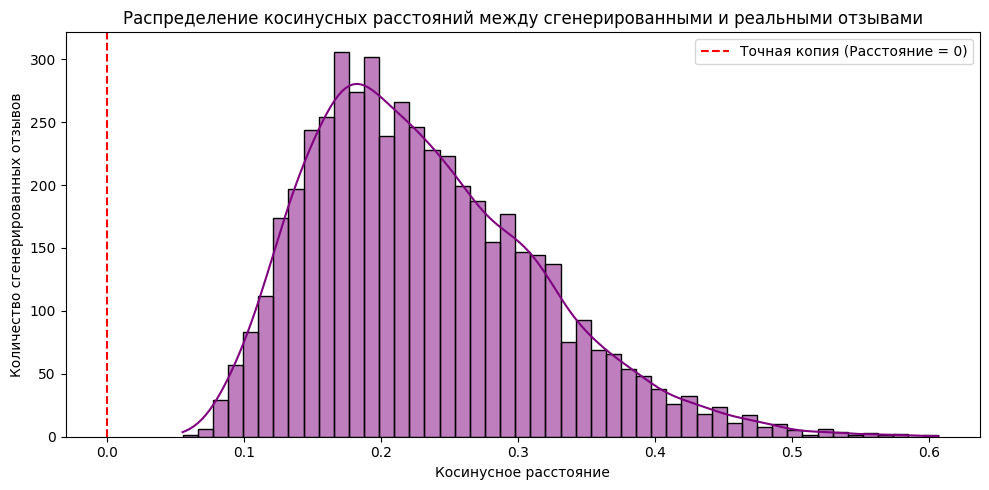

In [36]:
from sklearn.metrics.pairwise import cosine_distances

distances_list = []
# Считаем расстояние от каждого фейка до его ближайшего соседа
for i in range(len(X_fake)):
    fake_vec = X_fake[i].reshape(1, -1)
    mask = (y_real == y_fake[i])
    if mask.sum() > 0:
        dists = cosine_distances(fake_vec, X_real[mask])[0]
        distances_list.append(np.min(dists))

plt.figure(figsize=(10, 5))
sns.histplot(distances_list, bins=50, kde=True, color='purple')
plt.axvline(0.0, color='red', linestyle='--', label='Точная копия (Расстояние = 0)')
plt.title('Распределение косинусных расстояний между сгенерированными и реальными отзывами')
plt.xlabel('Косинусное расстояние')
plt.ylabel('Количество сгенерированных отзывов')
plt.legend()
plt.tight_layout()
plt.savefig('results/cosine_distances_hist.png', dpi=120)
plt.show()
